In [33]:
import pandas as pd
from collections import defaultdict

In [34]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# show all columns
pd.set_option("display.max_columns", None)

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [36]:
%%R

require('tidyverse')
require('DescTools')
require('ggplot2')
require('dplyr')


In [31]:
df = pd.read_csv("atp-output.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8771 entries, 0 to 8770
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 8771 non-null   int64  
 1   tournament           8771 non-null   object 
 2   surface              8771 non-null   object 
 3   five_set             8771 non-null   bool   
 4   player_A_name        8771 non-null   object 
 5   player_B_name        8771 non-null   object 
 6   player_A_elo_before  8771 non-null   float64
 7   player_B_elo_before  8771 non-null   float64
 8   player_A_win         8771 non-null   int64  
 9   elo_difference       8771 non-null   float64
 10  surface_cluster_A    8771 non-null   int64  
 11  surface_cluster_B    8771 non-null   int64  
 12  predict_proba_R      8771 non-null   float64
 13  predict_R            8771 non-null   int64  
dtypes: bool(1), float64(4), int64(5), object(4)
memory usage: 899.5+ KB


In [69]:
clay_df = df[df['surface']== 'Clay']
clay_df[clay_df['player_A_name'] == 'Rafael Nadal']

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
360,2024-07-29,Paris Olympics,Clay,False,Rafael Nadal,Novak Djokovic,1687.227519,1924.777018,0,-237.549500,1,1,0.265514,0
1009,2024-04-15,Barcelona,Clay,False,Rafael Nadal,Alex De Minaur,1673.215066,1819.976256,0,-146.761190,1,1,0.349051,0
1169,2024-04-22,Madrid Masters,Clay,False,Rafael Nadal,Alex De Minaur,1670.556012,1804.545805,1,-133.989793,1,1,0.361756,0
4770,2024-04-22,Madrid Masters,Clay,False,Rafael Nadal,Jiri Lehecka,1680.873712,1669.359375,0,11.514337,1,1,0.516036,1
6505,2022-05-02,Madrid Masters,Clay,False,Rafael Nadal,Miomir Kecmanovic,1715.901311,1646.141312,1,69.759999,1,2,0.623652,1
6852,2024-07-15,Bastad,Clay,False,Rafael Nadal,Cameron Norrie,1682.042002,1595.321055,1,86.720947,1,1,0.596472,1
6884,2022-05-23,Roland Garros,Clay,True,Rafael Nadal,Novak Djokovic,1745.340972,1656.924237,1,88.416735,1,1,0.658673,1
6920,2024-07-29,Paris Olympics,Clay,False,Rafael Nadal,Marton Fucsovics,1681.136529,1591.103344,1,90.033185,1,2,0.644082,1
7766,2024-04-15,Barcelona,Clay,False,Rafael Nadal,Flavio Cobolli,1664.199482,1515.868431,1,148.331050,1,2,0.699792,1
7834,2022-05-02,Madrid Masters,Clay,False,Rafael Nadal,David Goffin,1707.215044,1551.284510,1,155.930534,1,1,0.666269,1


In [59]:
player_a = clay_df[['player_A_name', 'player_A_win']].rename(columns={
    'player_A_name': 'player',
    'player_A_win': 'win'
})

player_b = clay_df[['player_B_name', 'player_A_win']].rename(columns={
    'player_B_name': 'player',
    'player_A_win': 'win'
})
# If player A wins, player B loses (i.e., 1 - win)
player_b['win'] = 1 - player_b['win']

# 3. Combine and group
all_players = pd.concat([player_a, player_b])

summary = all_players.groupby('player').agg(
    clay_matches_played=('win', 'count'),
    clay_matches_won=('win', 'sum')
).reset_index()

# 4. Calculate win percentage
summary['clay_win_pct'] = (summary['clay_matches_won'] / summary['clay_matches_played']) * 100

# 5. Sort by win percentage (optional)
summary = summary.sort_values(by='clay_win_pct', ascending=False)

summary[summary['clay_matches_played']>20].head(10)

,player,clay_matches_played,clay_matches_won,clay_win_pct
63,Carlos Alcaraz,80,69,86.250000
246,Matteo Berrettini,25,21,84.000000
286,Novak Djokovic,54,43,79.629630
334,Stefanos Tsitsipas,71,56,78.873239
22,Alexander Zverev,78,60,76.923077
65,Casper Ruud,94,72,76.595745
178,Jannik Sinner,44,33,75.000000
37,Andrey Rublev,61,44,72.131148
84,Daniil Medvedev,34,24,70.588235
309,Rafael Nadal,27,19,70.370370


### How has Alcaraz performed in head to heads with these players?

In [60]:
player_a = clay_df[['player_A_name', 'player_A_win']].rename(columns={
    'player_A_name': 'player',
    'player_A_win': 'win'
})
player_b = clay_df[['player_B_name', 'player_A_win']].rename(columns={
    'player_B_name': 'player',
    'player_A_win': 'win'
})
player_b['win'] = 1 - player_b['win']
all_players = pd.concat([player_a, player_b])
summary = all_players.groupby('player').agg(
    clay_matches_played=('win', 'count'),
    clay_matches_won=('win', 'sum')
).reset_index()
summary['clay_win_pct'] = (summary['clay_matches_won'] / summary['clay_matches_played']) * 100

# Step 3: Get top 10 players by clay win % (min. 20 matches)
top10_players = summary[summary['clay_matches_played'] > 20].sort_values(
    by='clay_win_pct', ascending=False).head(10)['player'].tolist()

# Step 4: Filter matches where Alcaraz played vs one of the other top 10
alcaraz_clay_h2h = clay_df[
    ((clay_df['player_A_name'] == 'Carlos Alcaraz') & (clay_df['player_B_name'].isin(top10_players))) |
    ((clay_df['player_B_name'] == 'Carlos Alcaraz') & (clay_df['player_A_name'].isin(top10_players)))
]

# Step 5: Determine opponent and whether Alcaraz won
def get_opponent(row):
    return row['player_B_name'] if row['player_A_name'] == 'Carlos Alcaraz' else row['player_A_name']

def alcaraz_won(row):
    if row['player_A_name'] == 'Carlos Alcaraz':
        return row['player_A_win']
    else:
        return 1 - row['player_A_win']

alcaraz_clay_h2h['opponent'] = alcaraz_clay_h2h.apply(get_opponent, axis=1)
alcaraz_clay_h2h['alcaraz_win'] = alcaraz_clay_h2h.apply(alcaraz_won, axis=1)

# Step 6: Summarize head-to-head
h2h_summary = alcaraz_clay_h2h.groupby('opponent').agg(
    matches_played=('alcaraz_win', 'count'),
    alcaraz_wins=('alcaraz_win', 'sum')
).reset_index()
h2h_summary['alcaraz_win_pct'] = (h2h_summary['alcaraz_wins'] / h2h_summary['matches_played']) * 100

# Display
print(h2h_summary.sort_values(by='alcaraz_win_pct', ascending=False))

             opponent  matches_played  alcaraz_wins  alcaraz_win_pct
3   Matteo Berrettini               1             1       100.000000
5        Rafael Nadal               1             1       100.000000
6  Stefanos Tsitsipas               4             4       100.000000
0    Alexander Zverev               4             3        75.000000
2       Jannik Sinner               2             1        50.000000
4      Novak Djokovic               3             1        33.333333
1       Andrey Rublev               1             0         0.000000


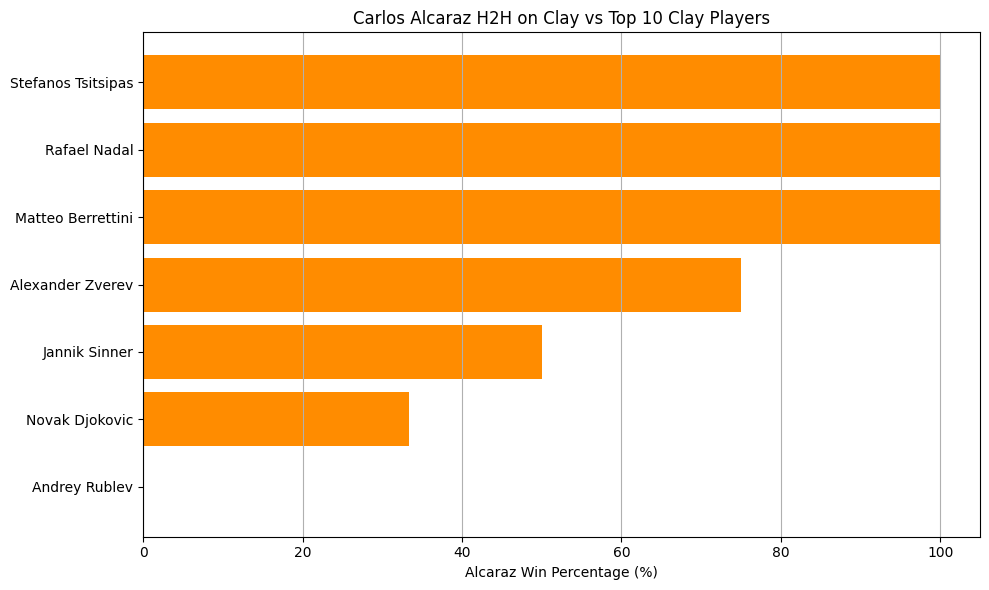

In [61]:
import matplotlib.pyplot as plt

# Sort by win percentage for clean plotting
h2h_sorted = h2h_summary.sort_values(by='alcaraz_win_pct', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(h2h_sorted['opponent'], h2h_sorted['alcaraz_win_pct'], color='darkorange')
plt.xlabel('Alcaraz Win Percentage (%)')
plt.title('Carlos Alcaraz H2H on Clay vs Top 10 Clay Players')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


In [48]:
pd.set_option('display.max_rows', None)
clay_df[(clay_df['player_A_name'] == 'Carlos Alcaraz') | (clay_df['player_B_name'] == 'Carlos Alcaraz')]


,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
18,20240729,Paris Olympics,Clay,False,Hady Habib,Carlos Alcaraz,1514.967309,1976.329142,0,-461.361833,2,1,0.136625,0
28,20240729,Paris Olympics,Clay,False,Roman Safiullin,Carlos Alcaraz,1534.795967,1974.419792,0,-439.623824,1,1,0.130664,0
36,20240527,Roland Garros,Clay,True,J J Wolf,Carlos Alcaraz,1462.202067,1893.702823,0,-431.500756,1,1,0.042089,0
62,20240219,Rio De Janeiro,Clay,False,Thiago Monteiro,Carlos Alcaraz,1489.194377,1870.295139,1,-381.100761,2,1,0.183166,0
73,20240212,Buenos Aires,Clay,False,Andrea Vavassori,Carlos Alcaraz,1522.646638,1890.804184,0,-368.157546,2,1,0.191727,0
115,20230529,Roland Garros,Clay,True,Denis Shapovalov,Carlos Alcaraz,1569.005683,1898.198379,0,-329.192695,1,1,0.084657,0
116,20230220,Rio De Janeiro,Clay,False,Dusan Lajovic,Carlos Alcaraz,1481.984755,1810.972996,0,-328.988242,2,1,0.219477,0
120,20230417,Barcelona,Clay,False,Roberto Bautista Agut,Carlos Alcaraz,1561.246935,1885.897279,0,-324.650344,1,1,0.198487,0
156,20230220,Rio De Janeiro,Clay,False,Mateus Alves,Carlos Alcaraz,1500.000000,1803.151541,0,-303.151541,0,1,0.023053,0
166,20240729,Paris Olympics,Clay,False,Felix Auger Aliassime,Carlos Alcaraz,1665.267411,1961.617910,0,-296.350499,1,1,0.218766,0


### Elo of top players over time

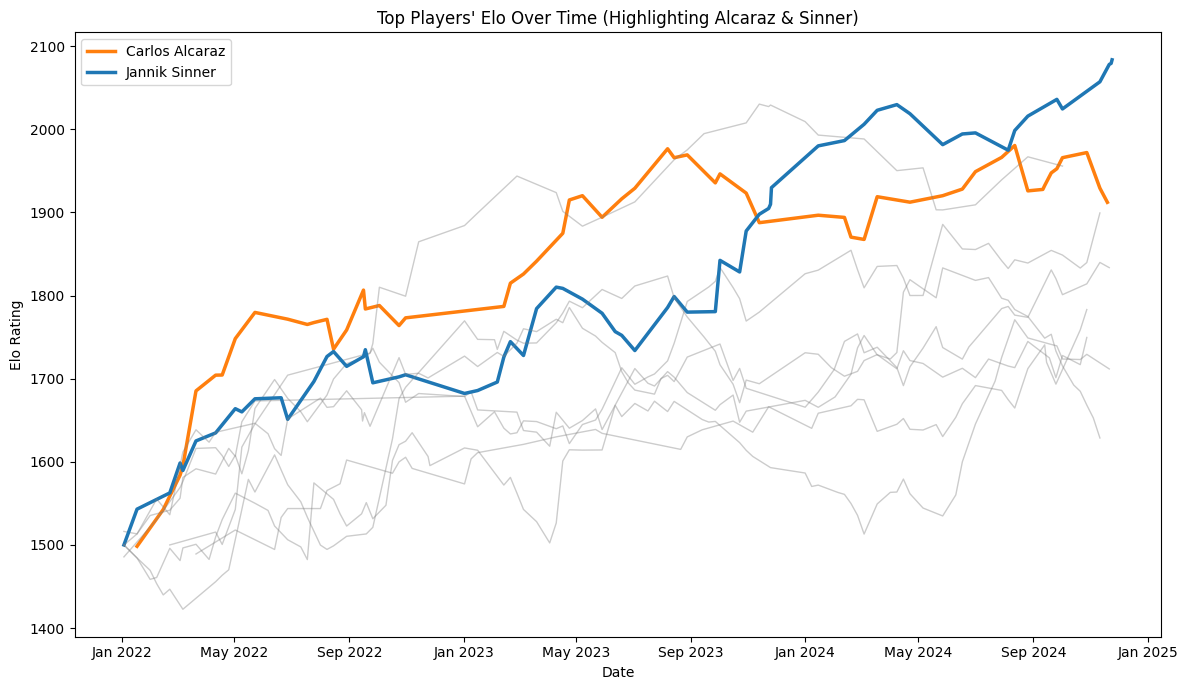

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load dataset
df = pd.read_csv("atp-output.csv")
df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d')

# Filter to only clay matches before 2025
df = df[df['date'].dt.year < 2025]

# Define top 10 clay players
top_players = [
    "Carlos Alcaraz", "Novak Djokovic", "Casper Ruud",
    "Alexander Zverev", "Jack Draper", "Jannik Sinner", "Alex de Minaur",
    "Taylor Fritz", "Holger Rune", "Lorenzo Musetti"]


# Gather Elo data
elo_a = df[df['player_A_name'].isin(top_players)][['date', 'player_A_name', 'player_A_elo_before']].rename(
    columns={'player_A_name': 'player', 'player_A_elo_before': 'elo'}
)
elo_b = df[df['player_B_name'].isin(top_players)][['date', 'player_B_name', 'player_B_elo_before']].rename(
    columns={'player_B_name': 'player', 'player_B_elo_before': 'elo'}
)
elo_df = pd.concat([elo_a, elo_b]).drop_duplicates(subset=['player', 'date'])

# Plot Elo over time
plt.figure(figsize=(12, 7))
for player in top_players:
    player_data = elo_df[elo_df['player'] == player].sort_values(by='date')
    color = 'tab:orange' if player == 'Carlos Alcaraz' else \
            'tab:blue' if player == 'Jannik Sinner' else 'gray'
    linewidth = 2.5 if player in ['Carlos Alcaraz', 'Jannik Sinner'] else 1
    alpha = 1.0 if player in ['Carlos Alcaraz', 'Jannik Sinner'] else 0.4
    plt.plot(player_data['date'], player_data['elo'], label=player if player in ['Carlos Alcaraz', 'Jannik Sinner'] else None, color=color, linewidth=linewidth, alpha=alpha)

# Format and display
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(False)
plt.title("Top Players' Elo Over Time (Highlighting Alcaraz & Sinner)")
plt.xlabel("Date")
plt.ylabel("Elo Rating")
plt.legend()
plt.tight_layout()
plt.show()


In [57]:
underdog_a = clay_df[(clay_df['predict_proba_R'] < 0.5) & (clay_df['player_A_win'] == 1)]
underdog_a = underdog_a[['player_A_name']].rename(columns={'player_A_name': 'player'})
underdog_a['upset_win'] = 1

# Step 3: Underdog wins from Player B side (predicted to lose, but won)
underdog_b = clay_df[(clay_df['predict_proba_R'] > 0.8) & (clay_df['player_A_win'] == 0)]
underdog_b = underdog_b[['player_B_name']].rename(columns={'player_B_name': 'player'})
underdog_b['upset_win'] = 1

# Step 4: Combine both sides of underdog wins
underdog_wins = pd.concat([underdog_a, underdog_b])

# Step 5: Count number of upset wins per player
upset_summary = underdog_wins.groupby('player').agg(
    upset_wins=('upset_win', 'sum')
).reset_index().sort_values(by='upset_wins', ascending=False)

# View top upset winners
print(upset_summary.head(10))

                      player  upset_wins
58       Francisco Cerundolo          10
150         Yannick Hanfmann           9
146  Tomas Martin Etcheverry           9
43             Dusan Lajovic           9
95           Lorenzo Musetti           8
34           Daniel Altmaier           8
72               Holger Rune           7
17            Aslan Karatsev           7
21   Bernabe Zapata Miralles           7
74               Hugo Gaston           6


## See all rows where prediction went wrong

In [12]:
df_filtered = df[df['player_A_win'] != df['predict_R']].sort_values(by='predict_proba_R', ascending=False)
df_filtered

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
8704,20240115,Australian Open,Hard,True,Grigor Dimitrov,Nuno Borges,1845.968429,1468.653977,0,377.314453,1,2,0.957648,1
8701,20230529,Roland Garros,Clay,True,Jannik Sinner,Daniel Altmaier,1778.715529,1404.601488,0,374.114041,1,1,0.939107,1
8197,20220829,Us Open,Hard,True,Taylor Fritz,Brandon Holt,1685.448494,1484.181722,0,201.266772,1,0,0.895420,1
8237,20240701,Wimbledon,Grass,True,Karen Khachanov,Quentin Halys,1688.869629,1480.472725,0,208.396904,1,2,0.894523,1
8356,20240115,Australian Open,Hard,True,Holger Rune,Arthur Cazaux,1729.387956,1499.967405,0,229.420551,1,3,0.886852,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,20220516,Geneva,Clay,False,Benoit Paire,Emil Ruusuvuori,1373.148471,1545.675008,1,-172.526538,0,1,0.039951,0
710,20230717,Gstaad,Clay,False,Zizou Bergs,Laslo Djere,1382.882479,1561.210227,1,-178.327748,0,1,0.038996,0
480,20230612,Stuttgart,Grass,False,Yibing Wu,Nick Kyrgios,1539.061196,1749.577844,1,-210.516649,3,1,0.035081,0
467,20240722,Umag,Clay,False,Chun Hsin Tseng,Fabio Fognini,1368.802854,1581.730241,1,-212.927387,0,1,0.033739,0


### Most surprising upsets

In [26]:
high_conf_upsets = df[
    (df['predict_R'] == 1) & 
    (df['predict_proba_R'] > 0.75) & 
    (df['player_A_win'] == 0)
]

# Display all columns of the filtered dataframe
pd.set_option('display.max_columns', None)


high_conf_upsets[high_conf_upsets['player_A_name'] == 'Alexander Zverev']

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
7299,20230203,Davis Cup QLS R1: GER vs SUI,Hard,False,Alexander Zverev,Marc Andrea Huesler,1660.169861,1547.940606,0,112.229255,1,0,0.763243,1
7612,20220221,Acapulco,Hard,False,Alexander Zverev,Peter Gojowczyk,1562.362690,1427.215773,0,135.146917,1,0,0.780755,1
8216,20230116,Australian Open,Hard,True,Alexander Zverev,Michael Mmoh,1665.164608,1459.487395,0,205.677213,1,3,0.868328,1
8464,20240715,Hamburg,Clay,False,Alexander Zverev,Arthur Fils,1862.807681,1608.939127,0,253.868554,1,1,0.753376,1
8698,20240226,Acapulco,Hard,False,Alexander Zverev,Daniel Altmaier,1831.082552,1461.205549,0,369.877004,1,1,0.822371,1


In [20]:
# 1. Filter for high-confidence upsets
high_conf_upsets = df[
    (df['predict_R'] == 1) & 
    (df['predict_proba_R'] > 0.75) & 
    (df['player_A_win'] == 0)
]

# 2. Count which Player B caused the most high-confidence upsets
high_conf_upsets['player_A_name'].value_counts()

player_A_name
Taylor Fritz                   10
Felix Auger Aliassime           7
Andrey Rublev                   5
Alexander Zverev                5
Jannik Sinner                   5
Holger Rune                     5
Stefanos Tsitsipas              5
Novak Djokovic                  4
Tallon Griekspoor               4
Ugo Humbert                     4
Carlos Alcaraz                  4
Karen Khachanov                 4
Casper Ruud                     4
Sebastian Korda                 3
Daniil Medvedev                 3
Grigor Dimitrov                 3
Rafael Nadal                    3
Frances Tiafoe                  3
Lorenzo Musetti                 3
Tommy Paul                      2
Ben Shelton                     2
Cem Ilkel                       2
Jack Draper                     2
Alejandro Davidovich Fokina     2
Hubert Hurkacz                  2
Pablo Carreno Busta             2
Lorenzo Sonego                  2
Andy Murray                     1
Roberto Bautista Agut           1


### Who performed better during a long match

In [15]:
long_matches_overall = df[(df['five_set'] == True) & (df['player_A_win'] == 1)]
long_matches_overall['player_A_name'].value_counts().head(50)

player_A_name
Novak Djokovic                 32
Carlos Alcaraz                 27
Jannik Sinner                  24
Alexander Zverev               20
Taylor Fritz                   18
Andrey Rublev                  18
Casper Ruud                    16
Daniil Medvedev                16
Grigor Dimitrov                14
Stefanos Tsitsipas             14
Karen Khachanov                13
Tommy Paul                     13
Frances Tiafoe                 12
Cameron Norrie                 12
Denis Shapovalov               12
Hubert Hurkacz                 11
Holger Rune                    11
Alex De Minaur                 10
Lorenzo Musetti                10
Tomas Martin Etcheverry         9
Botic Van De Zandschulp         9
Ben Shelton                     9
Corentin Moutet                 8
Alejandro Davidovich Fokina     8
Alexei Popyrin                  8
Daniel Evans                    7
Miomir Kecmanovic               7
Rafael Nadal                    7
Francisco Cerundolo             6


In [16]:
%%R -i long_matches_overall

# Step 1: Filter for 5-set wins as Player A and count them
long_match_wins <- long_matches_overall %>%
  filter(five_set == TRUE, player_A_win == 1) %>%
  count(player_A_name, sort = TRUE) %>%
  top_n(50, n)  # get top 50 players

# Optional: rename for clarity
colnames(long_match_wins) <- c("player", "wins")


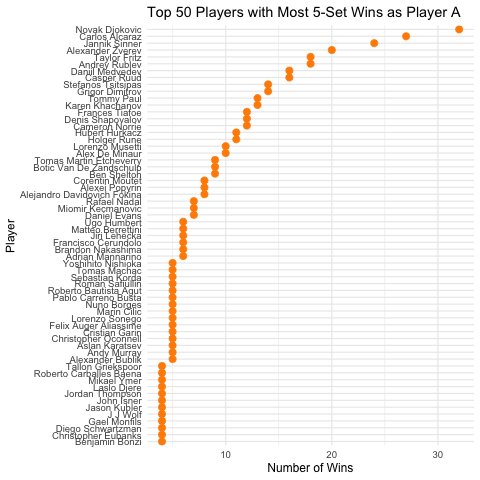

In [17]:
%%R
ggplot(long_match_wins, aes(x = reorder(player, wins), y = wins)) +
  geom_point(size = 3, color = "darkorange") +
  coord_flip() +
  labs(
    title = "Top 50 Players with Most 5-Set Wins as Player A",
    x = "Player",
    y = "Number of Wins"
  ) +
  theme_minimal(base_size = 12)


### ^^ They're all top players!

### Analyzing 2024 data

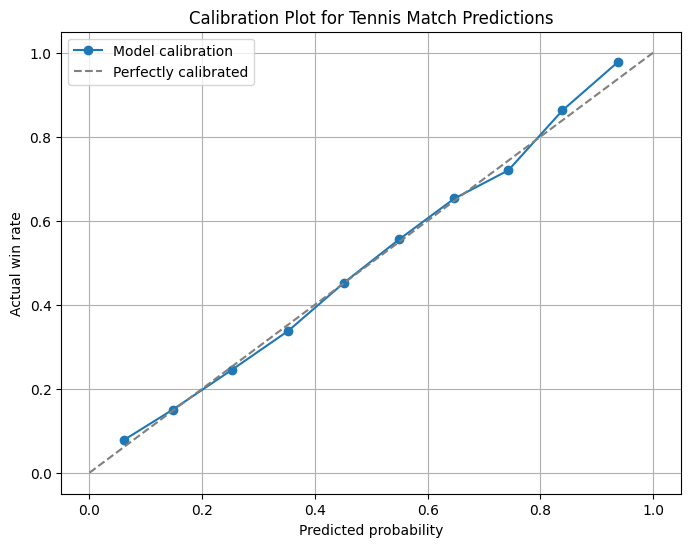

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Assuming your DataFrame is called df
# If not, replace 'df' with your actual DataFrame variable

# 1. Get predicted probabilities and actual outcomes
y_true = df['player_A_win']
y_prob = df['predict_proba_R']

# 2. Compute calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')

# 3. Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('Actual win rate')
plt.title('Calibration Plot for Tennis Match Predictions')
plt.legend()
plt.grid(True)
plt.show()